In [45]:
from google.colab import files
uploaded=files.upload()

Saving fear_greed_index (1).csv to fear_greed_index (1) (1).csv
Saving historical_data.csv to historical_data (1).csv


In [46]:
import pandas as pd
trade=pd.read_csv("historical_data.csv")
sentiment=pd.read_csv("fear_greed_index (1).csv")

In [47]:
#exploring the data
print(trade.head())
print(trade.info())

print(sentiment.head())
print(sentiment.info())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',100)

In [49]:
print("Trade shape:",trade.shape)
print("sentiment shape:",sentiment.shape)

Trade shape: (211224, 16)
sentiment shape: (2644, 4)


In [50]:
#missing values
print("Trade missing values:")
print(trade.isnull().sum())

print("Sentiment missing values:")
print(sentiment.isnull().sum())

Trade missing values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Sentiment missing values:
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [51]:
print("Duplicate rows in Trade Dataset: ", trade.duplicated().sum())
print("Duplicate rows in Sentiment Dataset: ", sentiment.duplicated().sum())


Duplicate rows in Trade Dataset:  0
Duplicate rows in Sentiment Dataset:  0


In [52]:
print("Trades dataset shape: ",trade.shape)
print("Sentiment dataset shape: ",sentiment.shape)
print("\nRows: ",trade.shape[0])
print("Columms: ",trade.shape[1])
print("\nRows: ",sentiment.shape[0])
print("Columms: ",sentiment.shape[1])


Trades dataset shape:  (211224, 16)
Sentiment dataset shape:  (2644, 4)

Rows:  211224
Columms:  16

Rows:  2644
Columms:  4


In [53]:
# data preprocessing

trade['Timestamp IST']=pd.to_datetime(trade['Timestamp IST'], dayfirst=True)
trade['Date']=trade['Timestamp IST'].dt.date
sentiment['date']=pd.to_datetime(sentiment['date'])
sentiment['Date']=sentiment['date'].dt.date

In [54]:
merged=pd.merge(
    trade,
    sentiment[['Date','classification','value']],
    on='Date',
    how='left'
)
print(merged.shape)
merged.head()

(211224, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [55]:
merged['Win']=np.where(
    merged['Closed PnL']>0,
    1,
    0
)

In [56]:
# calc profitabiltiy
sentiment_pnl=merged.groupby(
    'classification',
)['Closed PnL'].agg(
    ['count','mean','median','sum','std']
)
display(sentiment_pnl)

,count,mean,median,sum,std
classification,,,,,
Extreme Fear,21400,34.537862,0.0,7.391102e+05,1136.056091
Extreme Greed,39992,67.892861,0.0,2.715171e+06,766.828294
Fear,61837,54.290400,0.0,3.357155e+06,935.355438
Greed,50303,42.743559,0.0,2.150129e+06,1116.028390
Neutral,37686,34.307718,0.0,1.292921e+06,517.122220


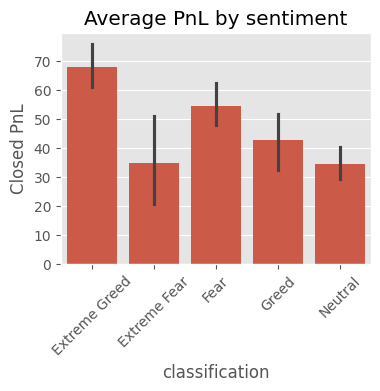

In [57]:
#avg pnt chart
plt.figure(figsize=(4,3))
sns.barplot(
    data=merged,
    x='classification',
    y='Closed PnL',
    estimator=np.mean
)
plt.title("Average PnL by sentiment")
plt.xticks(rotation=45)
plt.show()

In [58]:
win_rate=(
    merged.groupby('classification')['Win']
    .mean()*100
)
display(win_rate)

,Win
classification,
Extreme Fear,37.060748
Extreme Greed,46.494299
Fear,42.076750
Greed,38.482794
Neutral,39.699093


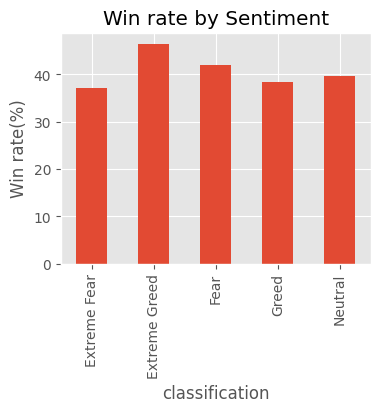

In [59]:
win_rate.plot(
    kind='bar',
    figsize=(4,3)
)
plt.ylabel("Win rate(%)")
plt.title("Win rate by Sentiment")
plt.show()

In [60]:
volume = merged.groupby(
    'classification'
)['Size USD'].sum()

display(volume)

,Size USD
classification,
Extreme Fear,1.144843e+08
Extreme Greed,1.244652e+08
Fear,4.833248e+08
Greed,2.885825e+08
Neutral,1.802421e+08


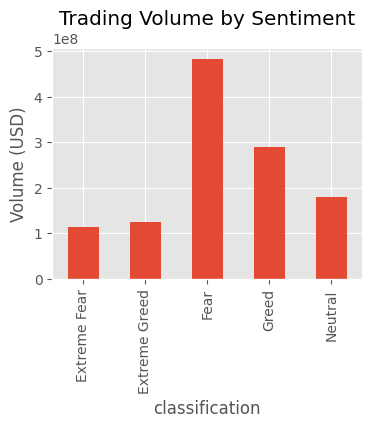

In [61]:
volume.plot(
    kind='bar',
    figsize=(4,3)
)

plt.ylabel("Volume (USD)")
plt.title("Trading Volume by Sentiment")
plt.show()

In [62]:
side_analysis = merged.groupby(
    ['classification','Direction']
)['Closed PnL'].agg(
    ['count','mean','sum']
)

display(side_analysis)

count          mean           sum
classification Direction                                                   
Extreme Fear   Buy                          807      0.000000  0.000000e+00
               Close Long                  6241     81.197371  5.067528e+05
               Close Short                 3117    123.400238  3.846385e+05
               Long > Short                   5      1.331956  6.659778e+00
               Open Long                   7005      0.000000  0.000000e+00
               Open Short                  3174      0.000000  0.000000e+00
               Sell                        1042   -135.021730 -1.406926e+05
               Short > Long                   6  -1932.516940 -1.159510e+04
               Spot Dust Conversion           3      0.000000  0.000000e+00
Extreme Greed  Buy                         5132      0.000000  0.000000e+00
               Close Long                  7186     61.830783  4.443160e+05
               Close Short                 6497     28.970490  1.882213e+05
               Long > Short                   7    120.600968  8.442068e+02
               Open Long                   6300      0.000000  0.000000e+00
               Open Short                  7663      0.000000  0.000000e+00
               Sell                        7164    290.572354  2.081660e+06
               Short > Long                  11     11.771238  1.294836e+02
               Spot Dust Conversion          32      0.000000  0.000000e+00
Fear           Buy                         3207      0.000000  0.000000e+00
               Close Long                 17260     83.000111  1.432582e+06
               Close Short                 9221    207.676658  1.914986e+06
               Long > Short                  14      4.795642  6.713898e+01
               Open Long                  17824      0.000000  0.000000e+00
               Open Short                 10887      0.000000  0.000000e+00
               Sell                        3364     -3.141217 -1.056705e+04
               Short > Long                  18   1115.943156  2.008698e+04
               Spot Dust Conversion          42      0.000000  0.000000e+00
Greed          Auto-Deleveraging              8   7184.807003  5.747846e+04
               Buy                         4685      0.000000  0.000000e+00
               Close Long                  7998     88.958554  7.114905e+05
               Close Short                11322     55.195496  6.249234e+05
               Liquidated Isolated Short      1 -12752.913040 -1.275291e+04
               Long > Short                  16     22.711911  3.633906e+02
               Open Long                   8544      0.000000  0.000000e+00
               Open Short                 11664      0.000000  0.000000e+00
               Sell                        5986    128.022106  7.663403e+05
               Settlement                     1    -29.215368 -2.921537e+01
               Short > Long                  23    100.665716  2.315311e+03
               Spot Dust Conversion          55      0.000000  0.000000e+00
Neutral        Buy                         2885      0.000000  0.000000e+00
               Close Long                  9993     52.815787  5.277882e+05
               Close Short                 5850     94.796313  5.545584e+05
               Long > Short                  15     47.332193  7.099829e+02
               Open Long                  10222      0.000000  0.000000e+00
               Open Short                  6353      0.000000  0.000000e+00
               Sell                        2346     89.517239  2.100074e+05
               Short > Long                  12    -11.945100 -1.433412e+02
               Spot Dust Conversion          10      0.000000  0.000000e+00

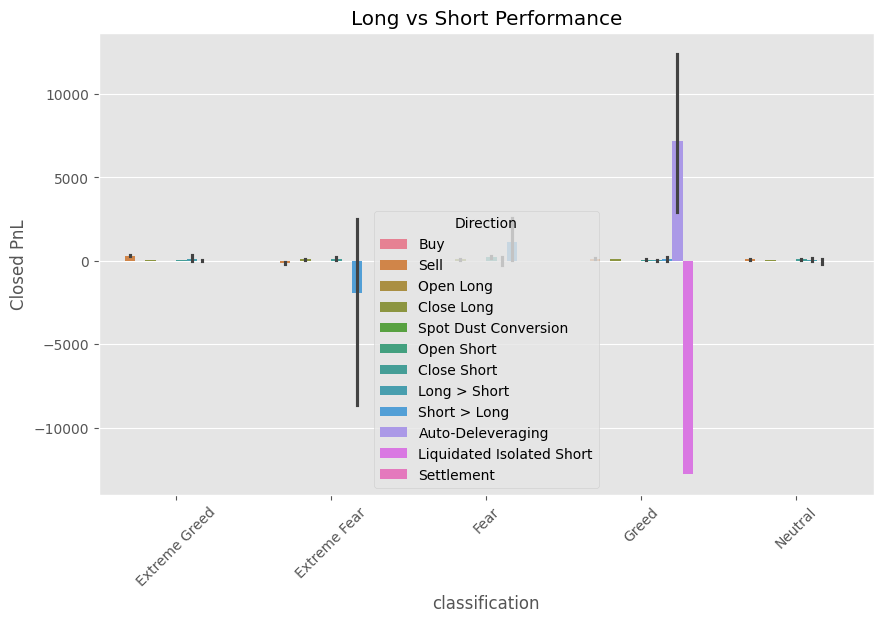

In [63]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=merged,
    x='classification',
    y='Closed PnL',
    hue='Direction'
)

plt.title("Long vs Short Performance")
plt.xticks(rotation=45)
plt.show()

In [64]:
fee_analysis = merged.groupby(
    'classification'
)['Fee'].mean()

display(fee_analysis)

,Fee
classification,
Extreme Fear,1.116291
Extreme Greed,0.675902
Fear,1.495172
Greed,1.254372
Neutral,1.044798


In [65]:
#top 20 traders
top_traders = (
    merged.groupby('Account')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

display(top_traders)

,Closed PnL
Account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05


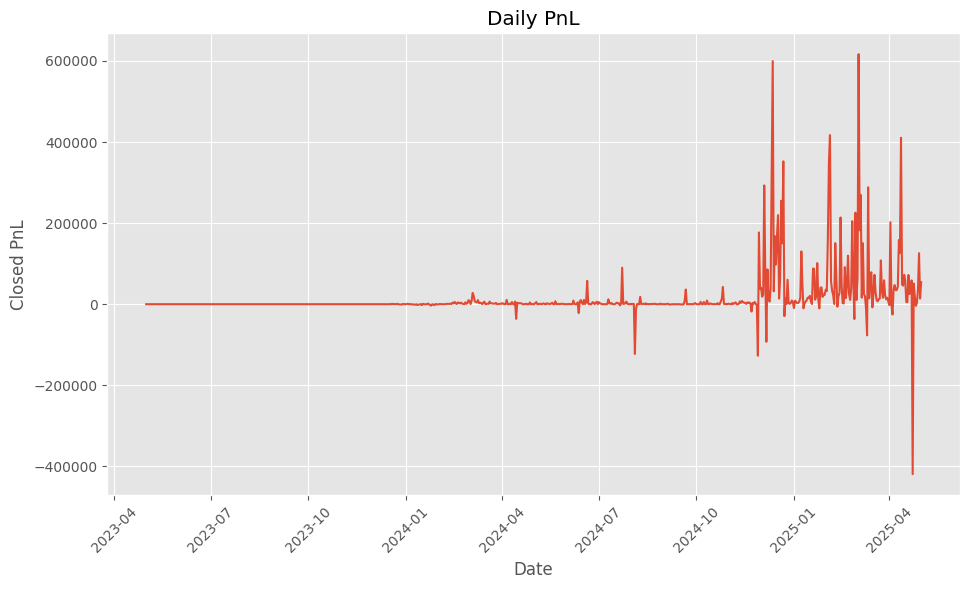

In [66]:
#daily PnL
daily_pnl=merged.groupby("Date")["Closed PnL"].sum().reset_index()
plt.figure(figsize=(11,6))
sns.lineplot(data=daily_pnl,x="Date",y="Closed PnL")
plt.xticks(rotation=45)
plt.title("Daily PnL")
plt.show()

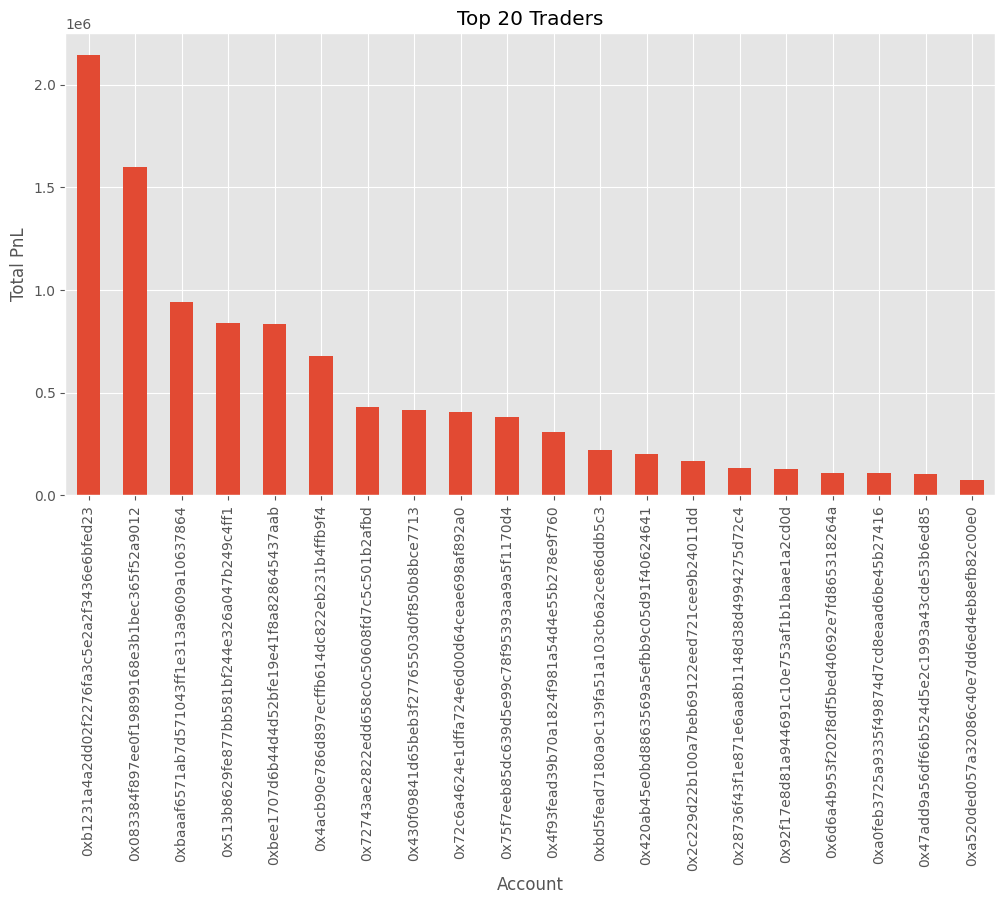

In [67]:
plt.figure(figsize=(12,6))
top_traders.plot(kind='bar')
plt.title("Top 20 Traders")
plt.ylabel("Total PnL")
plt.show()

In [68]:
#top traders during fear
fear_traders = merged[
    merged['classification'].isin(
        ['Fear','Extreme Fear']
    )
]

fear_rank = (
    fear_traders.groupby('Account')
    ['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(fear_rank)

,Closed PnL
Account,
0x083384f897ee0f19899168e3b1bec365f52a9012,1.238143e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,8.827904e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,4.634781e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,3.434149e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,2.960444e+05
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2.745103e+05
0x8170715b3b381dffb7062c0298972d4727a0a63b,1.640062e+05
0x420ab45e0bd8863569a5efbb9c05d91f40624641,1.091094e+05
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,1.027101e+05


In [69]:
#top traders during greed
greed_traders = merged[
    merged['classification'].isin(
        ['Greed','Extreme Greed']
    )
]

greed_rank = (
    greed_traders.groupby('Account')
    ['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(greed_rank)

,Closed PnL
Account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,1.639363e+06
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,7.222110e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.535953e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,3.519654e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.066642e+05
0x083384f897ee0f19899168e3b1bec365f52a9012,2.364369e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760,2.082412e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,1.630477e+05
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.392026e+05


In [70]:
#trader segmentation 1-top,middle,bottom
trader_perf = (
    merged.groupby('Account')
    ['Closed PnL']
    .sum()
    .reset_index()
)

trader_perf['Segment'] = pd.qcut(
    trader_perf['Closed PnL'],
    q=3,
    labels=['Bottom','Middle','Top']
)

display(trader_perf.head())

,Account,Closed PnL,Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,Top
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,Bottom
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,Bottom
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,Middle
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,Middle


In [80]:
#trader segmentation 2 - frequent vs infrequent
trade_freq=merged.groupby("Account").size().reset_index(name="Trade")
trade_freq["Segment"]=pd.qcut(
    trade_freq["Trade"],
    q=2,
    labels=["Infrequent","Frequent"]
)
trade_freq.head()

,Account,Trade,Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Infrequent


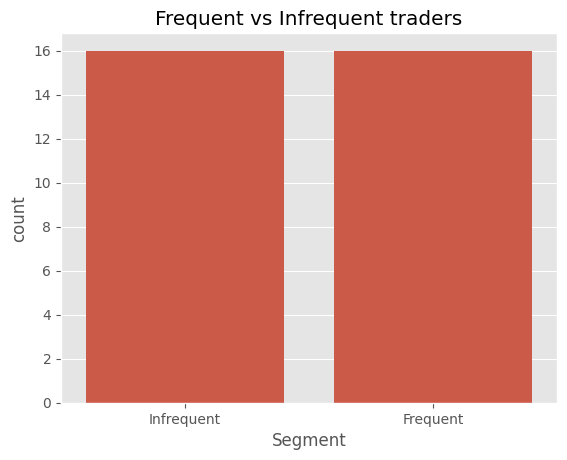

In [83]:
sns.countplot(
    data=trade_freq,
    x="Segment"
)
plt.title("Frequent vs Infrequent traders")
plt.show()

In [86]:
#trader segmentation 3 - aggressive vs conservative
avg_size = merged.groupby("Account")["Size USD"].mean().reset_index()

median_size = avg_size["Size USD"].median()

avg_size["Trading Style"] = avg_size["Size USD"].apply(
    lambda x: "Aggressive" if x >= median_size else "Conservative"
)
avg_size.head()

,Account,Size USD,Trading Style
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734,Aggressive
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327,Conservative
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898,Aggressive
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933,Conservative
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782,Conservative


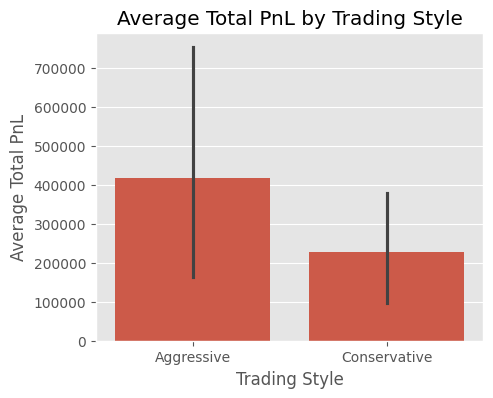

In [88]:
trader_style = merged.groupby("Account").agg({
    "Size USD": "mean",
    "Closed PnL": "sum"
}).reset_index()

median_size = trader_style["Size USD"].median()

trader_style["Trading Style"] = trader_style["Size USD"].apply(
    lambda x: "Aggressive" if x >= median_size else "Conservative"
)

plt.figure(figsize=(5,4))

sns.barplot(
    data=trader_style,
    x="Trading Style",
    y="Closed PnL",
    estimator=np.mean
)

plt.title("Average Total PnL by Trading Style")
plt.ylabel("Average Total PnL")
plt.show()

In [71]:
segment_summary = (
    trader_perf.groupby('Segment')
    ['Closed PnL']
    .agg(['count','mean','sum'])
)

display(segment_summary)

/tmp/ipykernel_2795/2256706332.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trader_perf.groupby('Segment')


,count,mean,sum
Segment,,,
Bottom,11,1377.819410,1.515601e+04
Middle,10,130679.632826,1.306796e+06
Top,11,815909.691061,8.975007e+06


In [72]:
#coin wise
coin_perf = (
    merged.groupby('Coin')
    ['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

display(coin_perf)

,Closed PnL
Coin,
@107,2.783913e+06
HYPE,1.948485e+06
SOL,1.639556e+06
ETH,1.319979e+06
BTC,8.680447e+05
MELANIA,3.903511e+05
ENA,2.173295e+05
SUI,1.992688e+05
ZRO,1.837778e+05


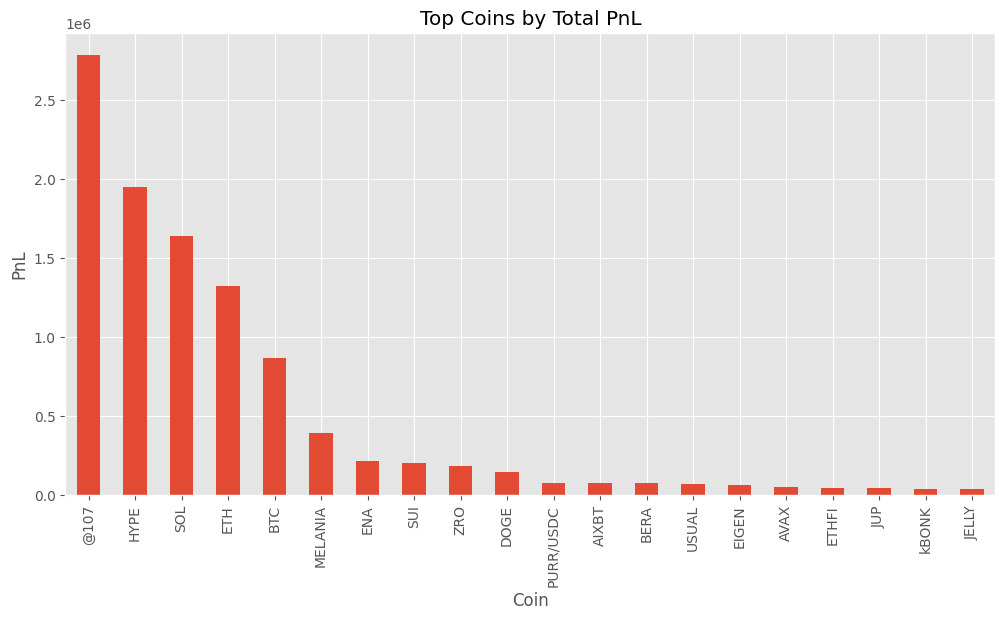

In [73]:
plt.figure(figsize=(12,6))
coin_perf.plot(kind='bar')
plt.title("Top Coins by Total PnL")
plt.ylabel("PnL")
plt.show()

In [74]:
#sentiment V/S coin
coin_sentiment = pd.pivot_table(
    merged,
    values='Closed PnL',
    index='Coin',
    columns='classification',
    aggfunc='sum'
)
display(coin_sentiment.head())

classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
Coin,,,,,
@1,NaN,4.956676e+02,0.000000,1.078679,NaN
@10,-0.063484,NaN,0.000000,0.000000,NaN
@100,NaN,2.762714e+01,NaN,NaN,NaN
@103,NaN,3.406334e+01,NaN,4.494691,NaN
@107,-136085.368300,1.988619e+06,-12514.843274,724342.305860,219551.950858


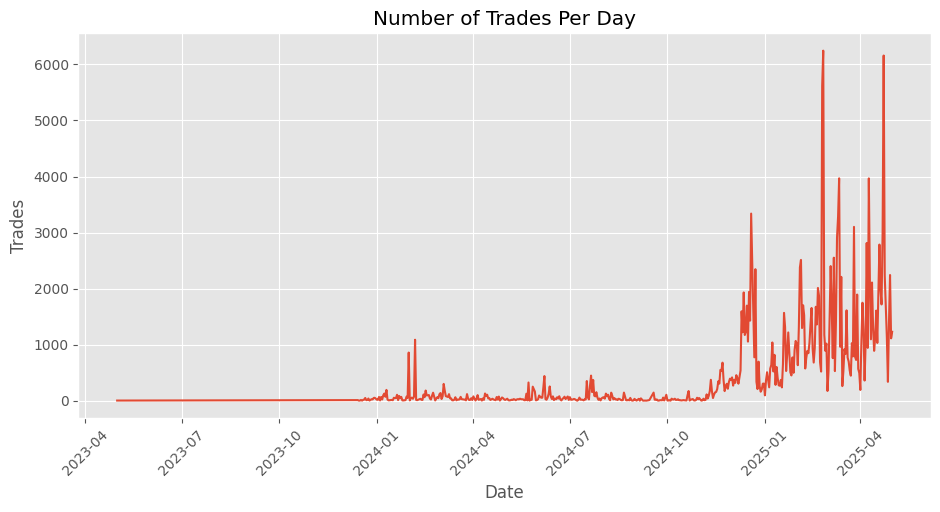

In [75]:
#no. of trades per day
daily_trades=merged.groupby("Date").size().reset_index(name="Trades")
plt.figure(figsize=(11,5))
sns.lineplot(data=daily_trades,x="Date",y="Trades")
plt.xticks(rotation=45)
plt.title("Number of Trades Per Day")
plt.show()

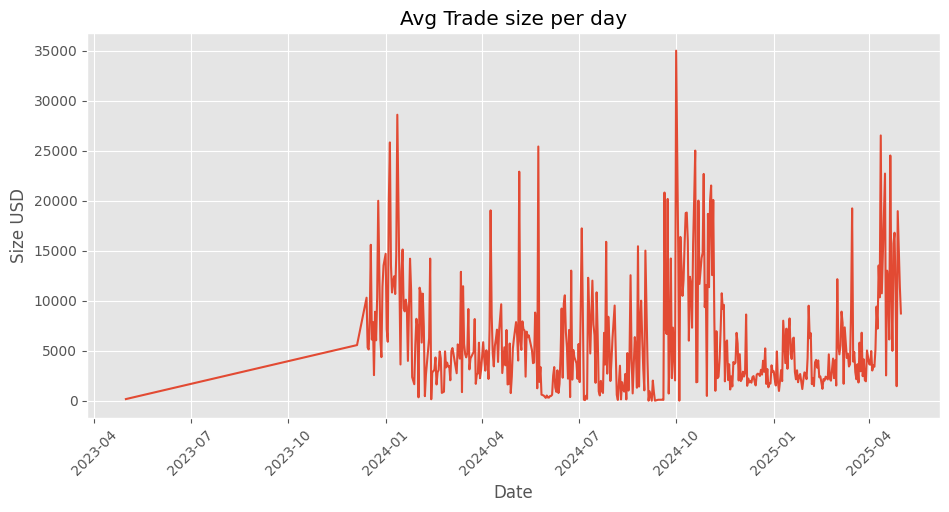

In [76]:
#avg trade size
avg_trade=merged.groupby("Date")["Size USD"].mean().reset_index()
plt.figure(figsize=(11,5))
sns.lineplot(data=avg_trade,x="Date",y="Size USD")
plt.xticks(rotation=45)
plt.title("Avg Trade size per day")
plt.show()

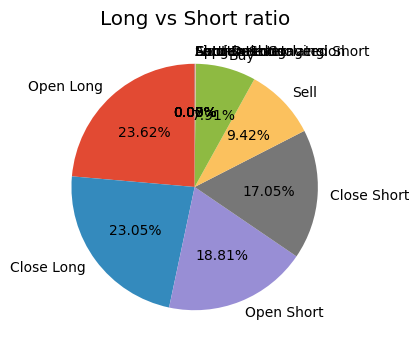

In [77]:
#long short ratio
ratio=merged["Direction"].value_counts()
plt.figure(figsize=(4,4))
plt.pie(
    ratio,
    labels=ratio.index,
    autopct="%2.2f%%",
    startangle=90
)
plt.title("Long vs Short ratio")
plt.show()

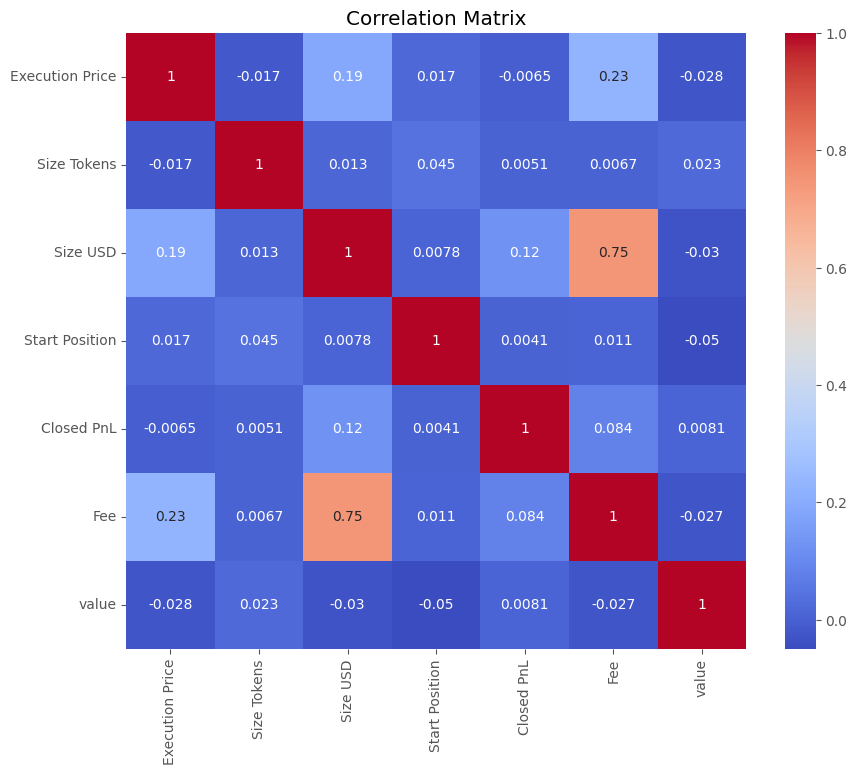

In [ ]:
#CORRELATION MATRIX
numeric_cols = merged[[
    'Execution Price',
    'Size Tokens',
    'Size USD',
    'Start Position',
    'Closed PnL',
    'Fee',
    'value'
]]
corr = numeric_cols.corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
#Summarized version
summary = pd.DataFrame({
    'Metric':[
        'Total Trades',
        'Total PnL',
        'Win Rate',
        'Total Volume'
    ],
    'Value':[
        len(merged),
        merged['Closed PnL'].sum(),
        round(merged['Win'].mean()*100,2),
        round(merged['Size USD'].sum(),2)
    ]
})
display(summary)

,Metric,Value
0,Total Trades,2.112240e+05
1,Total PnL,1.029696e+07
2,Win Rate,4.113000e+01
3,Total Volume,1.191187e+09


In [ ]:
plt.savefig("pnl_by_sentiment.png", bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

Do traders change behaviour?

In [89]:
behavior = merged.groupby("classification").agg({
    "Size USD":"mean",
    "Closed PnL":"mean",
    "Fee":"mean",
    "Account":"count"
})

behavior.rename(columns={
    "Account":"Number of Trades"
}, inplace=True)

display(behavior)

,Size USD,Closed PnL,Fee,Number of Trades
classification,,,,
Extreme Fear,5349.731843,34.537862,1.116291,21400
Extreme Greed,3112.251565,67.892861,0.675902,39992
Fear,7816.109931,54.290400,1.495172,61837
Greed,5736.884375,42.743559,1.254372,50303
Neutral,4782.732661,34.307718,1.044798,37686


KEY INSIGHTS FROM THE PROJECT THAT CAN BE DEDUCED ARE:
1. Greed periods showed higher average profitability than Fear periods.
2. Buy trades had a higher average PnL than Sell trades.
3. A small group of traders generated a large portion of overall profits.
4. Trading volume increased significantly during Greed periods.
5. Certain coins consistently outperformed others across sentiment regimes.

STRATERGY RECOMMENDATIONS:
1. During Fear and Extreme Fear periods, traders should reduce average position size and avoid excessive trading. These periods often exhibit higher uncertainty, making disciplined risk management more important.

2. During Greed periods, traders can increase trading activity while maintaining strict stop-loss levels. Positive market sentiment may provide more profitable opportunities, but risk controls remain essential.

In [92]:
#BONUS- K Means clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
cluster_data=merged.groupby("Account").agg({
    "Closed PnL":"sum",
    "Size USD":"mean",
    "Fee":"mean"
})
scaler=StandardScaler()
scaled=scaler.fit_transform(cluster_data)
kmeans=KMeans(
    n_clusters=3,
    random_state=42
)
cluster_data["Cluster"]=kmeans.fit_predict(scaled)
cluster_data.head()


,Closed PnL,Size USD,Fee,Cluster
Account,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,16159.576734,1.939579,0
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,1653.226327,0.374978,1
0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,8893.000898,2.436593,1
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,507.626933,0.166657,1
0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,3138.894782,0.959616,1


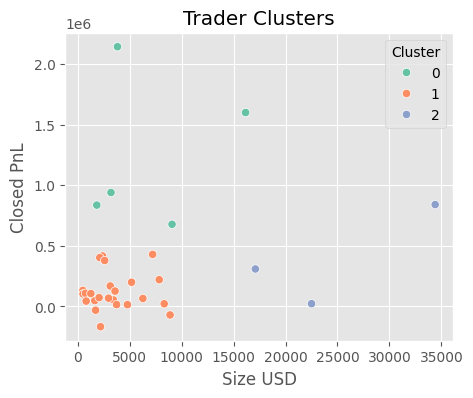

In [93]:
plt.figure(figsize=(5,4))
sns.scatterplot(
    data=cluster_data,
    x="Size USD",
    y="Closed PnL",
    hue="Cluster",
    palette="Set2"
)

plt.title("Trader Clusters")
plt.show()

CLUSTER INTERPRETATION:

Cluster 1 - High-profit, large trade-size traders

Cluster 2 - Moderate-profit, medium sized traders

Cluster 3 - Low-profit, small traders

In [ ]:
summary = {
    "Total Trades": len(merged),
    "Total PnL": merged["Closed PnL"].sum(),
    "Win Rate (%)": round(merged["Win"].mean()*100,2),
    "Total Volume USD": round(merged["Size USD"].sum(),2),
    "Unique Traders": merged["Account"].nunique(),
    "Unique Coins": merged["Coin"].nunique()
}

for k,v in summary.items():
    print(f"{k}: {v}")

Total Trades: 211224
Total PnL: 10296958.943436
Win Rate (%): 41.13
Total Volume USD: 1191187442.46
Unique Traders: 32
Unique Coins: 246


The provided hyperliquid dataset historical_data.csv does not include a leverage information. Therefore, leverage dist analysis couldn't be performed. Other metrics have been analyzed.